In [6]:
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Styling untuk visual
sns.set(style="whitegrid")
%matplotlib inline

### Data Wrangling

#### Gathering 

In [7]:
df = pd.read_csv("Advertising Dataset.csv")

#### Assessing

In [8]:
# Mengecek struktur data
df.info()

# Menampilkan 5 data teratas
print(df.head())

# Cek jumlah baris dan kolom
print(f"\nJumlah baris dan kolom: {df.shape}")

# Cek missing value
print("\nCek missing value:")
print(df.isnull().sum())

# Cek data duplikat
print("\nJumlah data duplikat:")
print(df.duplicated().sum())

# Cek statistik deskriptif
print("\nStatistik deskriptif:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Jumlah baris dan kolom: (200, 4)

Cek missing value:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Jumlah data duplikat:
0

Statistik deskriptif:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    

#### Cleaning

Karna dataset tidak ada missing serta duplikat maka proses ini tidak diperlukan

### Exploratory Data Analysis (EDA)

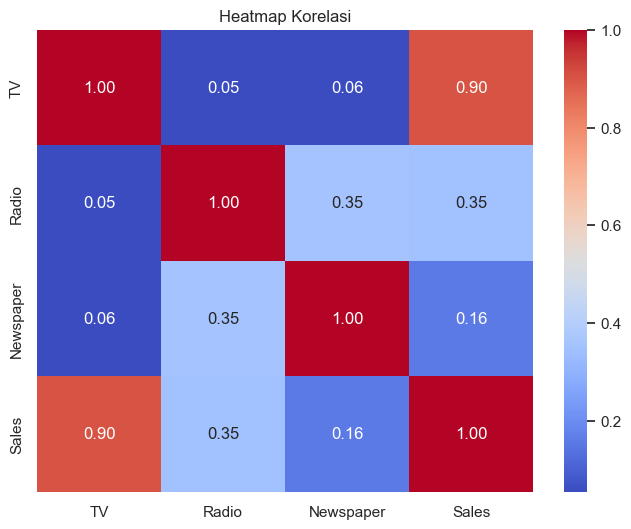

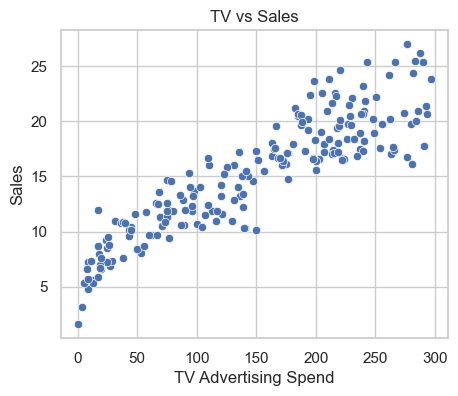

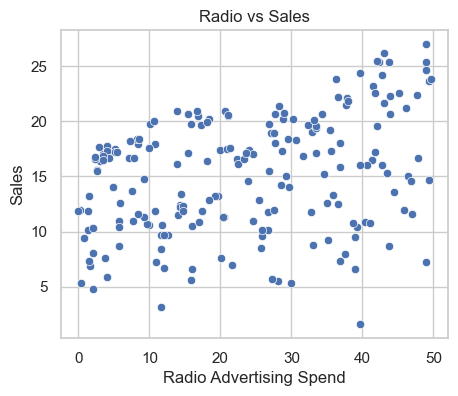

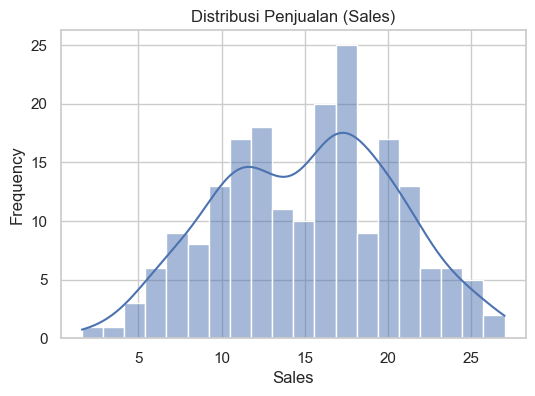

In [12]:
# 1. Korelasi antar variabel
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi')
plt.show()

# 2. Scatter plot tiap fitur terhadap Sales
features = ['TV', 'Radio']
for col in features:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=col, y='Sales', data=df)
    plt.title(f'{col} vs Sales')
    plt.xlabel(f'{col} Advertising Spend')
    plt.ylabel('Sales')
    plt.show()

# 3. Distribusi target (Sales)
plt.figure(figsize=(6, 4))
sns.histplot(df['Sales'], kde=True, bins=20)
plt.title('Distribusi Penjualan (Sales)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

Penjelasan singkat

1. Heatmap Korelasi
Nilai korelasi antara:

TV dan Sales = 0.90 sangat kuat

Radio dan Sales = 0.35 cukup lemah

TV dan Radio = 0.05 hampir tidak berkorelasi

Kesimpulan: TV adalah faktor paling dominan dalam mempengaruhi penjualan.

2. Scatter Plot
TV vs Sales: pola titik naik rapi - hubungan linier kuat

Radio vs Sales: lebih menyebar - pengaruhnya lebih kecil, tapi tetap bisa berkontribusi

3. Distribusi Sales
Distribusi Sales cukup simetris meskipun tidak sepenuhnya normal.

### Modelling Linear Regression

In [15]:
# 1. Pisahkan fitur (X) dan target (y)
X = df[['TV', 'Radio']]   
y = df['Sales']

# 2. Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inisialisasi dan latih model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Prediksi pada data test
y_pred = model.predict(X_test)

# 5. Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 6. Hasil
print("Koefisien regresi (TV, Radio):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Koefisien regresi (TV, Radio): [0.05450736 0.10325764]
Intercept: 4.791381661776025
Mean Squared Error (MSE): 2.846616122131541
R² Score: 0.9078797802624651


### Kesimpulan 

Hasil Utama:
Model regresi memiliki nilai R² sebesar 0.91, yang berarti model dapat menjelaskan 91% variasi penjualan berdasarkan pengeluaran iklan di TV dan Radio.

Pengaruh masing-masing media:

- TV: Koefisien 0.0545 artinya setiap kenaikan 1 unit pengeluaran iklan TV meningkatkan penjualan sebesar 0.0545 unit.

- Radio: Koefisien 0.1033 artinya setiap kenaikan 1 unit pengeluaran iklan Radio meningkatkan penjualan sebesar 0.1033 unit.

Radio memiliki pengaruh yang lebih besar per unit pengeluaran dibandingkan TV, meskipun TV memiliki korelasi lebih kuat secara keseluruhan terhadap penjualan.